In [1]:
import os
import sys
import textwrap

from huggingface_hub import notebook_login
from langchain import HuggingFacePipeline
from langchain.chains import RetrievalQA, RetrievalQAWithSourcesChain
from langchain.chains.question_answering import load_qa_chain
from langchain.document_loaders import PyPDFLoader, UnstructuredFileLoader
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.memory import ConversationBufferMemory
from langchain.prompts import PromptTemplate
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import pandas as pd


c:\Users\joeya\OneDrive2\OneDrive\Documentos\Cursos\Final Project\envfp\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# poner esto en terminal $env:HUGGINGFACE_TOKEN="tu_api_token_aquí"
# es mejor hacer el loggin por terminal así: huggingface-cli login --token "tu_api_token_aquí" --add-to-git-credential


#import os

#huggingface_api_token = os.getenv("HUGGINGFACE_TOKEN")


In [2]:
from preprocessing import convert_files_to_docs, process_documents

dir_path = "C:/Users/joeya/OneDrive2/OneDrive/Documentos/Cursos/Final Project/insurance_dataset/"
all_docs = convert_files_to_docs(dir_path)
docs_default, processed_docs = process_documents(all_docs)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\joeya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


['C:\\Users\\joeya/nltk_data', 'c:\\Users\\joeya\\OneDrive2\\OneDrive\\Documentos\\Cursos\\Final Project\\envfp\\nltk_data', 'c:\\Users\\joeya\\OneDrive2\\OneDrive\\Documentos\\Cursos\\Final Project\\envfp\\share\\nltk_data', 'c:\\Users\\joeya\\OneDrive2\\OneDrive\\Documentos\\Cursos\\Final Project\\envfp\\lib\\nltk_data', 'C:\\Users\\joeya\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']
n_docs_input: 9
n_docs_output: 1037


In [3]:
import pandas as pd

# Extraer el contenido de los documentos en una lista de textos usando la clave content
texts = [doc["content"] for doc in docs_default] 

# Crear DataFrame con los textos
df = pd.DataFrame({"text": texts})

# Agregar estadísticas de texto
df["num_words"] = df["text"].apply(lambda x: len(x.split()))
df["num_chars"] = df["text"].apply(lambda x: len(x))

# Mostrar estadísticas generales
print(df[["num_words", "num_chars"]].describe())  # Muestra distribución
print(f"Total words: {df['num_words'].sum()}")  # Suma total de palabras
print(f"Total chars: {df['num_chars'].sum()}")  # Suma total de caracteres

         num_words    num_chars
count  1037.000000  1037.000000
mean     79.869817   523.390550
std      22.907558   150.888785
min      12.000000    79.000000
25%      70.000000   441.000000
50%      83.000000   542.000000
75%      93.000000   612.000000
max     320.000000  1997.000000
Total words: 82825
Total chars: 542756


In [4]:
df.head()

,text,num_words,num_chars
0,PÓLIZA DE ACCIDENTES PERSONALES / REEMBOLSO GA...,74,510
1,ARTÍCULO 2º: COBERTURA Y MATERIA ASEGURADA\nLa...,51,363
2,"Lo anterior, cuando al asegurado le ocurra un ...",86,532
3,La compañía reembolsará los gastos referidos p...,149,947
4,Los reembolsos al Asegurado o pago al Prestado...,132,840


## Text Distribution

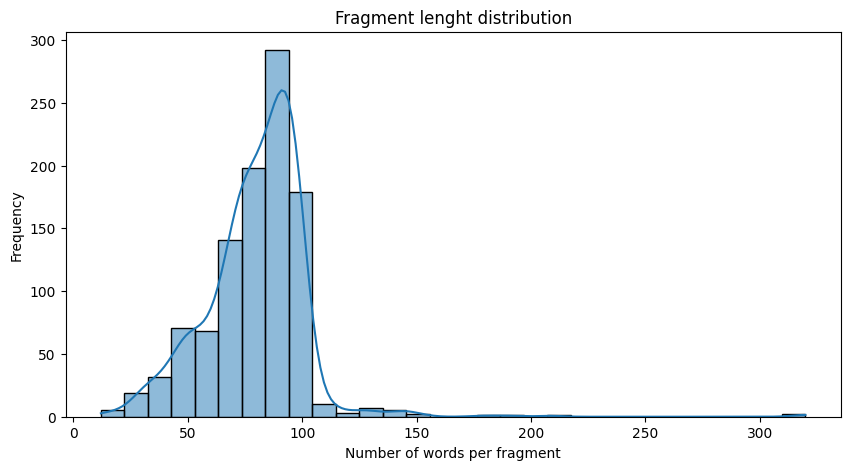

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(df["num_words"], bins=30, kde=True)
plt.xlabel("Number of words per fragment")
plt.ylabel("Frequency")
plt.title("Fragment lenght distribution")
plt.show()

In [6]:
from nltk.corpus import stopwords

import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joeya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def remove_stopwords(text, stop_words):
    # Dividir el texto en palabras
    words = text.split()
    # Filtrar las stopwords
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # Unir las palabras filtradas en un solo texto
    return " ".join(filtered_words)




In [8]:

text = " ".join(doc["content"] for doc in docs_default)

# Filtrar las stopwords
filtered_text = remove_stopwords(text, stop_words)

print(filtered_text)

PÓLIZA ACCIDENTES PERSONALES / REEMBOLSO GASTOS MÉDICOS Incorporada Depósito Pólizas bajo código POL120190177 ARTÍCULO 1°: REGLAS APLICABLES CONTRATO aplicarán presente contrato seguro disposiciones contenidas artículos siguientes normas legales carácter imperativo establecidas título VIII, Libro II, Código Comercio. embargo, entenderán válidas estipulaciones contractuales beneficiosas asegurado beneficiario. ARTÍCULO 2º: COBERTURA MATERIA ASEGURADA Compañía Aseguradora reembolsará asegurado pagará directamente prestador salud Gastos Médicos Razonables Acostumbrados Efectivamente Incurridos, vez otorgado pagado cobertura sistema salud previsional, seguros complementarios u beneficios contratados asegurado. anterior, asegurado ocurra accidente vigencia póliza demande internación hospitalaria gasto realice prestadores salud asegurador determine, período duración Reembolso establezca Condiciones Particulares Póliza, inicia fecha ocurrencia Accidente originados éste. definiciones conceptos

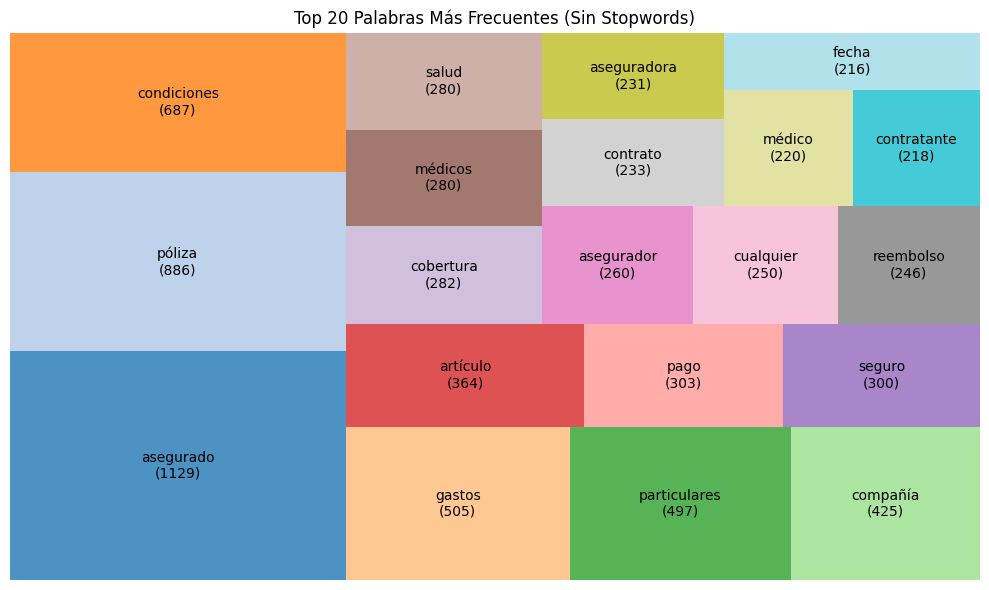

In [9]:
import squarify
from collections import Counter
import re

# Limpieza adicional del texto (eliminar puntuación y convertir a minúsculas)
filtered_text = re.sub(r'[^\w\s]', '', filtered_text.lower())

# Contar la frecuencia de las palabras
word_counts = Counter(filtered_text.split())

# Seleccionar las N palabras más comunes
top_n = 20
top_words = word_counts.most_common(top_n)

# Preparar datos para el treemap
words, counts = zip(*top_words)
sizes = list(counts)
labels = [f"{word}\n({count})" for word, count in top_words]

# Crear el treemap
plt.figure(figsize=(10, 6))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=plt.cm.tab20.colors)
plt.title(f'Top {top_n} Palabras Más Frecuentes (Sin Stopwords)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Analysis of possible categories or topics

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=100)
X = vectorizer.fit_transform([doc["content"] for doc in docs_default])

df_tfidf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf.head()

,accidente,acuerdo,al,aquellos,artículo,asegurado,asegurador,aseguradora,asegurados,bajo,...,su,sus,tales,titular,todo,tratamiento,tratamientos,términos,una,vigencia
0,0.000000,0.00000,0.366606,0.0,0.163975,0.099444,0.000000,0.000000,0.0,0.223316,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1,0.000000,0.00000,0.240496,0.0,0.161353,0.195709,0.000000,0.189120,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.148322,0.000000
2,0.346296,0.00000,0.084484,0.0,0.113363,0.068750,0.139952,0.000000,0.0,0.000000,...,0.104208,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.151602
3,0.201287,0.00000,0.049107,0.0,0.065893,0.079923,0.000000,0.000000,0.0,0.000000,...,0.060572,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.060572,0.176239
4,0.000000,0.13776,0.208487,0.0,0.000000,0.282767,0.000000,0.109299,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.130153,0.0,0.0,0.140027,0.000000,0.000000


## Analysis of entities and legal terms

In [11]:
import spacy
# to download the model run python -m spacy download es_core_news_sm in terminal

nlp = spacy.load("es_core_news_sm") 
doc = nlp(all_docs[0]["content"]) 

for ent in doc.ents:
    print(f"{ent.text} -> {ent.label_}")

PÓLIZA -> ORG
ACCIDENTES -> ORG
PERSONALES -> ORG
REEMBOLSO -> ORG
GASTOS MÉDICOS
Incorporada -> MISC
Depósito de Pólizas -> MISC
POL120190177
ARTÍCULO 1 -> MISC
REGLAS APLICABLES AL -> MISC
Libro II -> MISC
Código de Comercio -> LOC
ARTÍCULO -> ORG
COBERTURA -> MISC
MATERIA ASEGURADA
La Compañía Aseguradora -> MISC
Gastos Médicos Razonables -> MISC
Acostumbrados -> LOC
Efectivamente Incurridos -> LOC
Lo anterior -> MISC
determine -> PER
Reembolso -> PER
Condiciones Particulares de la Póliza -> ORG
Accidente -> MISC
Las definiciones de estos conceptos -> MISC
Condiciones Generales -> ORG
Accidente que los origina -> MISC
Asegurado -> ORG
Póliza -> LOC
Período de Duración de Reembolso -> PER
Deducible -> MISC
Condiciones Particulares de la Póliza -> ORG
Póliza -> LOC
Monto Máximo -> PER
Gastos Reembolsables -> LOC
Condiciones Particulares -> ORG
Póliza -> LOC
Artículo 5° -> MISC
Condiciones Generales -> ORG
prestador(es -> MISC
Condiciones Particulares -> ORG
Póliza -> LOC
Asegurado -> 

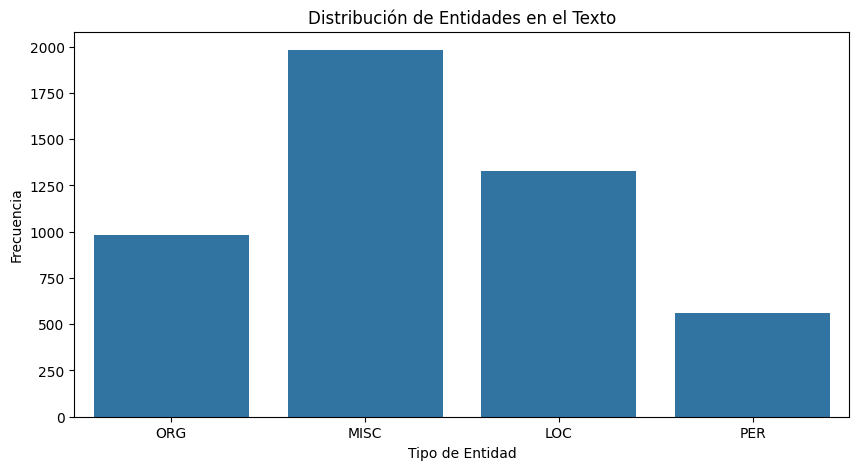

In [12]:
from collections import Counter

# Cargar modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")

# Procesar el texto
doc = nlp(text)

# Contar entidades por tipo
entities = [ent.label_ for ent in doc.ents]
entity_counts = Counter(entities)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(entity_counts.keys()), y=list(entity_counts.values()))
plt.xlabel("Tipo de Entidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de Entidades en el Texto")
plt.show()

In [13]:
from nltk.util import ngrams
import nltk

nltk.download('punkt')
tokens = nltk.word_tokenize(docs_default[0]["content"])

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))

bigram_freq = Counter(bigrams)
trigram_freq = Counter(trigrams)

print("Bigramas más comunes:", bigram_freq.most_common(10))
print("Trigramas más comunes:", trigram_freq.most_common(10))


Bigramas más comunes: [((',', 'del'), 2), (('PÓLIZA', 'DE'), 1), (('DE', 'ACCIDENTES'), 1), (('ACCIDENTES', 'PERSONALES'), 1), (('PERSONALES', '/'), 1), (('/', 'REEMBOLSO'), 1), (('REEMBOLSO', 'GASTOS'), 1), (('GASTOS', 'MÉDICOS'), 1), (('MÉDICOS', 'Incorporada'), 1), (('Incorporada', 'al'), 1)]
Trigramas más comunes: [(('PÓLIZA', 'DE', 'ACCIDENTES'), 1), (('DE', 'ACCIDENTES', 'PERSONALES'), 1), (('ACCIDENTES', 'PERSONALES', '/'), 1), (('PERSONALES', '/', 'REEMBOLSO'), 1), (('/', 'REEMBOLSO', 'GASTOS'), 1), (('REEMBOLSO', 'GASTOS', 'MÉDICOS'), 1), (('GASTOS', 'MÉDICOS', 'Incorporada'), 1), (('MÉDICOS', 'Incorporada', 'al'), 1), (('Incorporada', 'al', 'Depósito'), 1), (('al', 'Depósito', 'de'), 1)]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\joeya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Data Processing

In [ ]:
from langchain_core.documents import Document

langchain_docs = [
    Document(page_content=doc["content"], metadata=doc.get("meta", {}))  
    for doc in docs_default
]

In [15]:
from sentence_transformers import SentenceTransformer

embeddings_model = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-mpnet-base-v2',
    
)

C:\Users\joeya\AppData\Local\Temp\ipykernel_42692\3636612669.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings_model = HuggingFaceEmbeddings(


In [16]:
from langchain.vectorstores import FAISS

vectorstore = FAISS.from_documents(langchain_docs, embeddings_model)

## Model set up

In [ ]:
'''from transformers import AutoTokenizer


model_name = "HuggingFaceH4/zephyr-7b-alpha"  
tokenizer = AutoTokenizer.from_pretrained(model_name)'''


In [ ]:
'''from transformers import AutoModelForCausalLM
import torch 

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",  
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,  # Ahorrar memoria
)'''

Loading checkpoint shards: 100%|██████████| 8/8 [00:04<00:00,  1.72it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


In [ ]:
'''pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    device_map="auto", # if torch.cuda.is_available() else -1,  
    max_new_tokens=512,
    do_sample=False,
    #top_k=10,
    num_return_sequences=1,
    eos_token_id=tokenizer.eos_token_id,
)'''

Device set to use cuda:0


In [ ]:
'''llm = HuggingFacePipeline(pipeline=pipe, model_kwargs={'temperature': 0})'''

C:\Users\joeya\AppData\Local\Temp\ipykernel_42692\3060805201.py:1: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe, model_kwargs={'temperature': 0})


Clean Memory

In [21]:
import torch

def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Option using cloud inference

In [ ]:
from langchain.llms.base import LLM
from huggingface_hub import InferenceClient
from typing import Any, List, Mapping, Optional

class HuggingFaceInferenceLLM(LLM):
    model_name: str = "HuggingFaceH4/zephyr-7b-alpha"
    temperature: float = 0
    max_new_tokens: int = 512
    client: Any = None  
    
    def __init__(self, model_name=None, temperature=None, max_new_tokens=None, **kwargs):
        if model_name:
            kwargs["model_name"] = model_name
        if temperature is not None:
            kwargs["temperature"] = temperature
        if max_new_tokens:
            kwargs["max_new_tokens"] = max_new_tokens
        
        
        super().__init__(**kwargs)
        
        self.client = InferenceClient() #Si se loguean por terminal no es necesario poner el token acá
        #self.client = InferenceClient(token="tu_token_aquí") #Si no se loguean por terminal, poner el token acá
    
    @property
    def _llm_type(self) -> str:
        return "huggingface_inference"
    
    def _call(self, prompt: str, stop: Optional[List[str]] = None) -> str:
        response = self.client.text_generation(
            model=self.model_name,
            prompt=prompt,
            max_new_tokens=self.max_new_tokens,
            temperature=self.temperature,
            do_sample=self.temperature >= 0
        )
        
        if response.startswith(prompt):
            response = response[len(prompt):]
        return response
    
    @property
    def _identifying_params(self) -> Mapping[str, Any]:
        return {
            "model_name": self.model_name,
            "temperature": self.temperature,
            "max_new_tokens": self.max_new_tokens
        }

In [196]:
llm = HuggingFaceInferenceLLM(
    model_name="HuggingFaceH4/zephyr-7b-alpha",
    temperature=0.01,
    max_new_tokens=512
)

## FAQ Agent definition

In [ ]:
from langchain.schema import Document
import json

qa_file = "C:/Users/joeya/../Final Project/qna_polizas.json" #Poner la ruta correcta
with open(qa_file, "r", encoding="utf-8") as file:
    qna_data = json.load(file)



In [299]:
from langchain.prompts import PromptTemplate
from langchain.chains.question_answering import load_qa_chain
from langchain.docstore.document import Document

faq_template = """Eres un asistente especializado en pólizas de seguros de salud.
Responde con precisión según la información dada. Responde en el idioma en el que se hizo la pregunta.
Si la respuesta no está en el contexto u obtienes una respuesta irrelevante, o si la pregunta está relacionada con noticias, actualidad o si el usuario te saluda, 
responde con "No puedo encontrar información sobre esto en mis FAQs".

Contexto: {context}

Pregunta: {question}
Respuesta:"""

qa_prompt = PromptTemplate(template=faq_template, input_variables=["context", "question"])
faq_chain = load_qa_chain(llm, chain_type="stuff", prompt=qa_prompt)




In [ ]:

qa_docs = [Document(page_content=qa["answer"], metadata={"question": qa["question"]}) for qa in qna_data]
qna_db = FAISS.from_documents(qa_docs, embeddings_model)
qna_db.save_local("insurance_qna_db")

def qna_search(search_input, threshold=0.75):
    """Busca en la base de datos de FAQs los documentos más similares a la pregunta."""
    qa_docs = qna_db.similarity_search_with_score(search_input, k=5)  
    sorted_docs = sorted(qa_docs, key=lambda x: x[1])  
    
    filtered_docs = [doc[0] for doc in sorted_docs if doc[1] < threshold]
    return filtered_docs


In [302]:
def faq_agent_original(question):
    """Searches for answers in the FAQs database or passes to the next agent if no relevant matches."""
    
    docs = qna_search(question, threshold=0.75)
    
    if not docs:
        return {"response": "Pasar al siguiente agente"}

    most_relevant_doc = docs[0]
    combined_context = most_relevant_doc.page_content

    try:
        prompt = f"Contexto: {combined_context}\nPregunta: {question}\nRespuesta:"
        direct_response = llm.invoke(prompt)

        if direct_response and "no puedo encontrar información" not in direct_response.lower():
            response_start = direct_response.lower().find("respuesta:")
            if response_start != -1:
                answer = direct_response[response_start + len("Respuesta:"):].strip()

            else:
                answer = direct_response.strip()

                if "Explicación:" in answer:
                    answer = answer.split("Explicación:")[0].strip()

                return {"response": answer.split("\n")[0].strip()}
           # return {"response": direct_response}
    except Exception as e:
        print(f"Error en la aproximación directa: {e}")

    try:
        response = faq_chain({"input_documents": [most_relevant_doc], "question": question})
        output_text = response.get("output_text", response).strip()
        final_answer = output_text.split("Respuesta:")[-1].strip()

        if "Explicación:" in final_answer:
            final_answer = final_answer.split("Explicación:")[0].strip()

        return {"response": final_answer.split("\n")[0].strip()} if final_answer else {"response": "Pasar al siguiente agente"}
    except Exception as e:
        print(f"Error en faq_chain: {e}")
        return {"response": "Pasar al siguiente agente"}


def faq_agent_adapter(state):
    """Adapts the input/output format of faq_agent_original to work with LangGraph."""

    question = state.get("question", "")
    #print(f"FAQ Agent recibiendo: {question}")  # Debug
    
    result = faq_agent_original(question)
    #print(f"FAQ Agent resultado: {result}")  # Debug
    
    new_state = state.copy()
    if isinstance(result, dict) and "response" in result:
        new_state["response"] = result["response"]
        #if result["response"] != "Pasar al siguiente agente":
            #print(f"FAQ Agent encontró respuesta: {result['response']}")
            #print(f"{result['response']}")
    
    return new_state

In [ ]:

#print(faq_agent_adapter({"question": "¿Qué sucede si el asegurado no paga la prima?"}))


{'question': '¿Qué sucede si el asegurado no paga la prima?', 'response': 'El contrato termina a los 15 días de la notificación del asegurador. El asegurador puede exigir el pago de la prima devengada y los gastos de formalización. El pago posterior no impide la terminación por nuevos atrasos. Terminada la vigencia, cesa la responsabilidad del asegurador.'}


In [ ]:
#print(faq_agent_adapter({"question":"¿Cómo se realiza el pago de primas?",}))

{'question': '¿Cómo se realiza el pago de primas?', 'response': 'El pago de primas se realiza a más tardar el último día hábil del mes de inicio del período, según se indica en las condiciones particulares.'}


## RAG Agent Definition

In [ ]:
from langchain.prompts import PromptTemplate
from langchain.chains import LLMChain

rag_template = """Eres un asistente especializado en pólizas de seguros de salud.
Responde con precisión según la información de los documentos proporcionados. Responde en el idioma en el que se hizo la pregunta.
Si la respuesta no está en el contexto u obtienes una respuesta irrelevante, o si la pregunta está relacionada con noticias, actualidad o si el usuario te saluda,
responde con "no puedo encontrar información".

Context: {context}
Question: {question}
Answer:"""


prompt_template = PromptTemplate(
    input_variables=["context", "question"],
    template=rag_template
)


format_chain = LLMChain(llm=llm, prompt=prompt_template)

In [ ]:
def search(search_input, threshold=0.7):
    try:
        pdf_docs = vectorstore.similarity_search_with_score(search_input, k=3)
        
     
        filtered_docs = [doc[0].page_content for doc in pdf_docs if doc[1] >= threshold]
        
        #if not filtered_docs:
            #print("RAG Agent: No se encontraron documentos relevantes.")
        return filtered_docs
    except Exception as e:
        print(f"Error en search(): {e}")
        return []



In [ ]:

def rag_agent(question, threshold=0.7):  
    try:
        context = search(question, threshold)
        
        if not context:
            #print("RAG Agent: No hay documentos relevantes, pasando al siguiente agente.")
            return {"response": "Pasar al siguiente agente"}

        context_str = "\n".join(context)
    except Exception as e:
        print(f"Error en la búsqueda de contexto: {e}")
        return {"response": "Pasar al siguiente agente"}

    try:
        response = format_chain.invoke({"context": context_str, "question": question})

       
        answer = response["text"].split("Answer:")[-1].strip()

        # Validaciones adicionales para respuestas irrelevantes
        invalid_responses = ["no puedo encontrar información", "no está relacionada", "no sé"]
        if any(phrase in answer.lower() for phrase in invalid_responses) or len(answer) < 10:
            #print("RAG Agent: Respuesta irrelevante, pasando al siguiente agente.")
            return {"response": "Pasar al siguiente agente"}
        
        return {"response": answer}
    except Exception as e:
        print(f"Error en la generación de respuesta: {e}")
        return {"response": "Pasar al siguiente agente"}

def rag_agent_adapter(state):
    """Adapta el formato de entrada/salida del RAG Agent para funcionar con LangGraph."""
    clear_gpu_memory()  
    
    question = state.get("question", "")
    #print(f"RAG Agent recibiendo: {question}")  # Debug
    
    result = rag_agent(question)
    #print(f"RAG Agent resultado: {result}")  # Debug
    
    new_state = state.copy()
    new_state["current_agent"] = "RAG"  
    
    if isinstance(result, dict) and "response" in result:
        if result["response"] != "Pasar al siguiente agente":
            new_state["response"] = result["response"]
            #print(f"RAG Agent encontró respuesta: {result['response']}")
            #print(f"{result['response']}")
    
    return new_state




In [ ]:
#print(rag_agent_adapter({"question": "¿Qué se entiende por 'Prótesis Quirúrgicas'?"}))

{'question': "¿Qué se entiende por 'Prótesis Quirúrgicas'?", 'current_agent': 'RAG', 'response': "'Prótesis Quirúrgicas' se refiere a la implantación de dispositivos o aparatos externos que se utilizan para sostener, alinear o prevenir deformidades, o mejorar la función de partes móviles del cuerpo, como resultado de una operación quirúrgica."}


In [ ]:
#print(rag_agent_adapter({"question": "¿Qué se entiende por 'órtesis'?"}))

'Órtesis' se refiere a un dispositivo o aparato externo que se utiliza para sostener, alinear o prevenir deformidades, o mejorar la función de partes móviles del cuerpo.
{'question': "¿Qué se entiende por 'órtesis'?", 'current_agent': 'RAG', 'response': "'Órtesis' se refiere a un dispositivo o aparato externo que se utiliza para sostener, alinear o prevenir deformidades, o mejorar la función de partes móviles del cuerpo."}


## Google Agent Definition

In [245]:
google_template = """Eres un asistente especializado en pólizas de seguros de salud.
Responde con precisión realizando una búsqueda en Google, en las páginas que se te proporcionó, también
puedes usar información de tu entrenamiento. Responde en el idioma en el que se hizo la pregunta. Da una respuesta clara y concisa, no incluyas información irrelevante.
Si no sabes la respuesta, la respuesta no está en el contexto o si te piden noticias, actualidad, novedades o similares responde con "no puedo encontrar información".

Contexto: {context}

Pregunta: {question}
Respuesta:"""

google_prompt = PromptTemplate(template=google_template, input_variables=["context", "question"])

In [ ]:
from googleapiclient.discovery import build

# Configuración de la API de Google
API_KEY = ""  # Clave de API
SEARCH_ENGINE_ID = "c3b71a5283d724339"  #  ID de motor de búsqueda

In [ ]:
def google_agent(query, num_results=5):
    """Realiza una búsqueda en Google y extrae información relevante."""
    try:
        service = build("customsearch", "v1", developerKey=API_KEY)
        
        result = service.cse().list(
            q=query,
            cx=SEARCH_ENGINE_ID,
            num=num_results
        ).execute()

        search_results = result.get("items", [])
        if not search_results:
            #print("Google Agent: No se encontraron resultados.")
            return "Pasar al siguiente agente"

        context = " ".join([item.get("snippet", "") for item in search_results if item.get("snippet")])

        if not context.strip():
            #print("Google Agent: No hay contenido válido en los resultados.")
            return "Pasar al siguiente agente"

        document = Document(page_content=context)

        gprompt = google_prompt.format(context=context, question=query)

        google_chain = load_qa_chain(llm, chain_type="stuff", prompt=google_prompt)
        full_response = google_chain.run(input_documents=[document], question=query)

        respuesta = full_response.split("Respuesta:", 1)[-1].strip()

        if "Pregunta:" in respuesta:
            respuesta = respuesta.split("Pregunta:")[0].strip()

        if not respuesta or "no encontró la respuesta" in respuesta.lower():
            #print("Google Agent: Respuesta no válida.")
            return "Pasar al siguiente agente"

        #print(f"Google Agent: {respuesta}")
        #print(f"{respuesta}")
        return respuesta

    except Exception as e:
        print(f"Error en Google Agent: {e}")
        return "Pasar al siguiente agente"

def google_agent_adapter(state):
    """Adapta la entrada/salida de Google Agent para LangGraph."""
    clear_gpu_memory()  

    question = state.get("question", "")
    #print(f"Google Agent recibiendo: {question}")  # Debug
    
    result = google_agent(question)
    #print(f"Google Agent resultado: {result}")  # Debug
    
    new_state = state.copy()
    new_state["current_agent"] = "Google"

    if (
        not result  # Si es None o vacío
        or isinstance(result, str) and len(result.strip()) < 10  # Si es una respuesta demasiado corta
        or "no puedo encontrar" in result.lower()  # Respuestas genéricas de fallo
        or "no tengo información" in result.lower()
        or "lo siento" in result.lower()
    ):
        #print("Google Agent no encontró respuesta relevante, pasando al siguiente agente.")
        new_state["response"] = "Pasar al siguiente agente"
    else:
        new_state["response"] = result
        #print(f"Google Agent encontró respuesta: {result}")
        #print(f"{result}")
    
    return new_state

In [ ]:
#query = "Qué se entiende por 'animales de compañía'?"
#response = google_agent(query)
#print("Respuesta del Google Agent:", response)

#print(google_agent_adapter({"question": "¿Qué se entiende por Prótesis Quirúrgicas?"}))

Animales de compañía se refiere a los mamíferos, aves, reptiles y peces que se mantienen como mascotas o como compañeros de vida por sus propiedades de compañía, como la capacidad de ser entrenados, la capacidad de ser domesticados o la capacidad de ser mantenidos en cautiverio. Estos animales incluyen perros, gatos, hamsteres, conejos, pájaros, serpientes y peces.
Respuesta del Google Agent: Animales de compañía se refiere a los mamíferos, aves, reptiles y peces que se mantienen como mascotas o como compañeros de vida por sus propiedades de compañía, como la capacidad de ser entrenados, la capacidad de ser domesticados o la capacidad de ser mantenidos en cautiverio. Estos animales incluyen perros, gatos, hamsteres, conejos, pájaros, serpientes y peces.


In [ ]:
#question = "¿Qué se entiende por 'Siniestro'?"
#response = google_agent(question)

#print("Respuesta del Google Agent:", response)

Un siniestro es un evento que causa daño o pérdida a una persona, una propiedad o un negocio, y que puede ser cubierto por una póliza de seguro. En este caso, la persona está esperando una respuesta sobre un siniestro que no fue su responsabilidad.
Respuesta del Google Agent: Un siniestro es un evento que causa daño o pérdida a una persona, una propiedad o un negocio, y que puede ser cubierto por una póliza de seguro. En este caso, la persona está esperando una respuesta sobre un siniestro que no fue su responsabilidad.


## News Agent Definition

In [ ]:
from langchain_core.documents import Document
from langchain.chains.question_answering import load_qa_chain
from googleapiclient.discovery import build

news_template = """Eres un asistente especializado en pólizas de seguros de salud.
Responde con precisión realizando una búsqueda sobre seguros de salud en Chile e internacionalmente. 
Genera un breve resumen de las noticias más relevantes encontradas, en lugar de listar titulares. Responde en el idioma en el que se hizo la pregunta.
Si no encuentras información relevante, dilo claramente.

Contexto: {context}

Pregunta: {question}
Resumen:"""

news_prompt = PromptTemplate(template=news_template, input_variables=["context", "question"])

API_KEY = ""  # Clave de API
NEWS_ENGINE_ID = "809f46b767fe14d69"  # ID de motor de búsqueda

In [327]:
def news_agent(query, num_results=10):
    """Busca noticias recientes sobre seguros de salud en Google News y genera un breve resumen."""
    try:
        service = build("customsearch", "v1", developerKey=API_KEY)

        result = service.cse().list(
            q=f"seguros de salud {query}",
            cx=NEWS_ENGINE_ID,
            num=num_results,
            #searchType="news"
        ).execute()

        search_results = result.get("items", [])
        if not search_results:
            return "No se encontraron noticias relevantes sobre seguros de salud."

        context = " ".join([item.get("snippet", "") for item in search_results if item.get("snippet")])

        document = Document(page_content=context)

        gprompt = news_prompt.format(context=context, question=query)

        google_news_chain = load_qa_chain(llm, chain_type="stuff", prompt=news_prompt)

        full_response = google_news_chain.run(input_documents=[document], question=query)

        resumen = full_response.split("Resumen:", 1)[-1].strip()

        return resumen

    except Exception as e:
        print(f"Error en google_news_agent: {e}")
        return "Error al obtener noticias de Google."


def news_agent_adapter(state):
    """Adapta el formato de entrada/salida del Google News Agent para LangGraph."""
    clear_gpu_memory()

    question = state.get("question", "")
    #print(f"Google News Agent recibiendo: {question}")  # Debug

    result = news_agent(question)

    new_state = state.copy()

    if result and "No se encontraron noticias" not in result:
        new_state["response"] = result
        #print(f"Google News Agent encontró respuesta: {result}")
    else:
        new_state["response"] = "Pasar al siguiente agente"
        print("No he podido encontrar respuesta, prueba reformulando la pregunta.")

    new_state["current_agent"] = "Google News"

    return new_state

In [ ]:
#query = "Noticias sobre Seguros de salud em chile"
#resultado = news_agent(query)
#print(resultado)


En Chile, la cobertura de salud universal se ha convertido en una meta inalcanzable sin acceso universal, oportuno y efectivo. Los seguros privados financiados por el Estado son la opción principal en Estados Unidos, mientras que en la región, la salud pública enfrenta nuevos desafíos como la reemergencia de enfermedades infecciosas y cambios en aspectos políticos. En Chile, el número de pólizas contratadas ha aumentado en un 39,6% en relación con el primer semestre de este año, llegando a 806.325. Sin embargo, según el último estudio global de Ipsos, el 74% de la población cree que en Chile las personas transgénero son discriminadas. La PAHO trabaja con los países de la región para mejorar la salud y la calidad de vida de sus poblaciones.


## LangGraph Agents Chain

In [ ]:
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key="chat_history"
)

In [ ]:
from langgraph.graph import StateGraph
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END



def router(state):
    """Determina el siguiente nodo basado en el estado actual."""
    #print(f"Router state antes de decisión: {state}")
    
    if "response" in state and state["response"] and state["response"] != "Pasar al siguiente agente":
        #print(f"Respuesta válida encontrada en router: {state['response']}")
        return END

    if state.get("current_agent") == "FAQ":
        #print("Pasando de FAQ a RAG")
        return "RAG"

    if state.get("current_agent") == "RAG":
        #print("Pasando de RAG a Google")
        return "Google"

    if state.get("current_agent") == "Google":
        #print("Pasando de Google a News")
        return "News"

    if state.get("current_agent") == "News":
        #print("Finalizando flujo en News")
        return END

    #print("Finalizando flujo por defecto")
    return END


graph = StateGraph(state_schema=dict)


faq_node = graph.add_node("FAQ", RunnableLambda(faq_agent_adapter))
rag_node = graph.add_node("RAG", RunnableLambda(rag_agent_adapter))
google_node = graph.add_node("Google", RunnableLambda(google_agent_adapter))
news_node = graph.add_node("News", RunnableLambda(news_agent_adapter))


graph.add_conditional_edges(
    "FAQ",
    router,
    {
        "RAG": "RAG",
        END: END
    }
)

graph.add_conditional_edges(
    "RAG",
    router,
    {
        "Google": "Google",
        END: END
    }
)

graph.add_conditional_edges(
    "Google",
    router,
    {
        "News": "News",
        END: END
    }
)

graph.add_edge("News", END)

graph.set_entry_point("FAQ")

chain = graph.compile()


def Final_Agent(query):
    """Executes the LangGraph flow and returns the first valid response."""
    #print(f"Procesando consulta: {query}")
    
    try:
        clear_gpu_memory()

        chat_history = memory.load_memory_variables({}).get("chat_history", [])
        
        # Crear el estado inicial incluyendo el historial
        initial_state = {
            "question": query,
            "current_agent": "FAQ",
            "chat_history": chat_history
        }


        result = chain.invoke(initial_state)
        #print(f"Resultado del grafo (tipo: {type(result)}): {result}")

        # Verificar si el resultado es un diccionario válido
        if isinstance(result, dict):
            #print(f"Estado final después del grafo: {result}")

            # Si hay una respuesta válida, devolverla
            if "response" in result and result["response"] and result["response"] != "Pasar al siguiente agente":
                #print(f"Respuesta final encontrada: {result['response']}")
                #return f"Answer: {result['response']}"
                memory.save_context(
                    {"input": query},
                    {"output": result["response"]}
                )

                return f"{result['response']}"
        
        # Si el resultado es un string válido, devolverlo
        elif isinstance(result, str) and result and result != "Pasar al siguiente agente":

            memory.save_context(
                {"input": query},
                {"output": result}
            )
            
            #print(f"Respuesta string encontrada: {result}")
            #return f"Answer: {result}"
            return f"{result}"

        # Si ninguna de las condiciones anteriores se cumple, no hay respuesta válida
        #print("No se encontró una respuesta adecuada.")
        return "No se encontró una respuesta adecuada."
    
    except Exception as e:
        print(f"Error en Final_Agent: {e}")
        return f"Error procesando la consulta: {str(e)}"



In [ ]:
#def clear_memory():
    #"""Limpia la memoria de conversación."""
    #memory.clear()

In [ ]:
#print(Final_Agent("¿Qué sucede si el asegurado no paga la prima?")) 

El contrato termina a los 15 días de la notificación del asegurador. El asegurador puede exigir el pago de la prima devengada y los gastos de formalización. El pago posterior no impide la terminación por nuevos atrasos. Terminada la vigencia, cesa la responsabilidad del asegurador.


In [ ]:
#print(Final_Agent("¿Qué se entiende por 'Accidente'?")) 

Un 'Accidente' es un suceso imprevisto, involuntario, repentino y fortuito, causado por medios externos y de modo violento, que afecta al organismo del asegurado, ocasionándole lesiones visibles o internas.


In [ ]:
#print(memory.load_memory_variables({}))

In [ ]:
#print(Final_Agent("¿Qué se entiende por 'Animales de compañía'?")) 

En el contexto de la póliza de seguros de salud, 'Animales de compañía' se refiere a mascotas domésticas que se mantienen como compañías de los asegurados, como perros, gatos, hamsteres, etc. Estos animales no se consideran como una parte integral de la familia, pero se les considera como mascotas de compañía debido a su relación con los asegurados. La cobertura de animales de compañía puede ser opcional y puede tener limitaciones en la cobertura y los costos de la póliza.


In [ ]:
#print(Final_Agent("¿Qué se entiende por 'ortesis'?")) 

'Ortesis' se refiere a un dispositivo o aparato externo que se utiliza para sostener, alinear o prevenir deformidades, o mejorar la función de partes móviles del cuerpo.


In [ ]:
#print(Final_Agent("Noticias sobre Seguros de salud em chile")) 

El Panamericano de Salud (OPS) trabaja con los países de las Américas para mejorar la salud y la calidad de vida de sus poblaciones. Sin acceso universal, oportuno y efectivo, la cobertura universal se convierte en una meta inalcanzable. En Estados Unidos, no hay cobertura de salud universal pública, pero hay seguros privados financiados por el estado. En Chile, según el último estudio global de Ipsos "Orgullo LGBT+ 2024", el 74% cree que las personas transgénero son discriminadas. La salud pública en la región enfrenta nuevos desafíos como la reemergencia de enfermedades infecciosas y cambios en aspectos políticos. Al cierre del primer semestre de este año, el número de pólizas contratadas llegó a 806.325, con un alza de 39,6% en relación a los 577.394 de la misma fecha del año anterior.


In [ ]:
#print(Final_Agent("Crea un resumen de noticias de Seguros de salud em chile")) 

La Ley N° 20.850, del Ministerio de Salud, crea un sistema de protección financiera para diagnósticos y tratamientos de alto costo. Además, Zurich Insurance Group ha acordado la venta de su operación de Rentas Vitalicias. En materia de información en salud, se ha publicado un estudio sobre la utilización de prestaciones de salud, gasto en salud y cobertura en la industria de seguros de salud chileno.


In [ ]:
#print(Final_Agent("Cuáles son las últimas noticias de seguros de salud?")) 

En los últimos tiempos, se han realizado estudios sobre la cobertura universal de salud y los riesgos personales y beneficios asegurados. También se han discutido los recortes de la Administración Trump y la eliminación de la exención del Impuesto sobre las Primas de Seguros. Además, se han reportado disparidades regionales en la cobertura universal de salud y la necesidad de asistencia psicológica en seguros de salud. Sin embargo, no se han encontrado noticias específicas sobre seguros de salud en Chile o internacionalmente.


In [ ]:
#print(Final_Agent("What is the meaning of 'Accident'?")) 

An 'Accident' is an unexpected, involuntary, sudden and fortuitous event, caused by external means and in a violent manner, which affects the body of the insured, causing visible or internal injuries.


In [ ]:
#print(Final_Agent("¿Qué es el Período de Duración del Reembolso?")) 

El Período de Duración del Reembolso es el tiempo que tiene un beneficiario para solicitar el reembolso de las prestaciones otorgadas dentro del período de vigencia de beneficios. El reembolso se efectuará mediante dinero efectivo, cheque u otro medio de pago. El período de duración del reembolso es de 10 días desde que se recibió el producto. En los casos en los que se requiera un período más largo, se establecerá un período de vacancia para el ejercicio de los derechos. Cualquier otro beneficiario tendrá derecho solamente al reembolso del gasto que pruebe haber realizado hasta el momento en que se establezca el período de vacancia.
